# 1.) Analyse exploratoire initiale

## Collecte et Affichage des données

In [141]:
# Importation des librairies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [142]:
# Importer la dataframe
df = pd.read_csv(os.path.join(os.getcwd(), '..', 'data', 'predictive_maintenance.csv'))

In [143]:
# 5 premières lignes
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [144]:
# 5 dernières lignes
df.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


In [145]:
df.shape

(10000, 14)

In [146]:
# type de chaque colonne
df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Nous avons 14 colonnes dont 2 sont qualitatives

In [147]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## Comprehension des variable

## 📊 Description des variables du dataset

---

### 1. 🌡️ `Air Temperature [K]` — Température de l'air
Représente la **température ambiante** autour de la machine

---

### 2. 🔥 `Process Temperature [K]` — Température du process
- Représente la **chaleur générée** à l'intérieur du process de fabrication
- ⚠️ La **différence entre ces deux températures** est cruciale : si elle est trop faible, la chaleur ne se dissipe pas correctement → **risque de panne**

---

### 3. ⚙️ `Rotational Speed [rpm]` — Vitesse de rotation
Mesure la **vitesse de rotation** de l'outil / de la broche

---

### 4. 🔩 `Torque [Nm]` — Couple
- Mesure la **force de rotation** appliquée
- ⚠️ Un couple trop élevé ou trop faible peut signaler un **problème**

---

### 5. 🪛 `Tool Wear [min]` — Usure de l'outil
- Temps **cumulé d'utilisation** de l'outil en minutes
- Taux d'usure par cycle selon le type de produit :
  - **H** (haute qualité) → **5 min/cycle**
  - **M** (qualité moyenne) → **3 min/cycle**
  - **L** (basse qualité) → **2 min/cycle**
- ⚠️ Plus l'outil est usé, plus le **risque de casse augmente**

---

### 6. Type (issu de Product ID)
Variable qualité produit (feature catégorielle importante)

---

### 7. Variables cibles (les étiquettes = ce qu'on veut prédire = Y)

Il y a 6 variables cibles, toutes binaires (0 = pas de panne, 1 = panne) : 
- Vaut 1 si AU MOINS UN des 5 modes de défaillance ci-dessous est vrai.
- C'est la variable cible principale pour un modèle de classification binaire.
- Important : on ne sait PAS depuis cette variable laquelle des 5 pannes a eu lieu.



# 2.) Traitement des données

In [148]:
# Identifier les variables avec valeurs manquantes
df.isnull().sum() 

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Aucunes valeurs manquantes

In [149]:
# Compter les doublons
df.duplicated().sum() 

np.int64(0)

Aucun doublon détecté

In [150]:
# Détecter erreurs lexicales sur variables qualitatives
df.describe(include=['O']) 

,Product ID,Type
count,10000,10000
unique,10000,3
top,L57163,L
freq,1,6000


Aucune de lexicale détectée ; Cependant la catégorie L représente 60% des données. La Distribution déséquilibrée : L domine largement sur M et H

In [151]:
# Détection des outliers par méthode IQR
numeric_cols = ['Air temperature [K]', 'Process temperature [K]', 
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    pct = n_outliers / len(df) * 100
    
    outlier_summary.append({
        'Variable': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Borne inf': round(lower, 2),
        'Borne sup': round(upper, 2),
        'N outliers': n_outliers,
        '% outliers': round(pct, 2)
    })

pd.DataFrame(outlier_summary).sort_values('N outliers', ascending=False)

,Variable,Q1,Q3,IQR,Borne inf,Borne sup,N outliers,% outliers
2,Rotational speed [rpm],1423.0,1612.0,189.0,1139.50,1895.50,418,4.18
3,Torque [Nm],33.2,46.8,13.6,12.80,67.20,69,0.69
0,Air temperature [K],298.3,301.5,3.2,293.50,306.30,0,0.00
1,Process temperature [K],308.8,311.1,2.3,305.35,314.55,0,0.00
4,Tool wear [min],53.0,162.0,109.0,-110.50,325.50,0,0.00


In [152]:
# Vérifier si les outliers sont des vraies pannes
cols = ['Torque [Nm]', 'Rotational speed [rpm]']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask_out = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)
    
    print(f"\n{'='*40}")
    print(f"Colonne : {col}")
    print(f"Outliers détectés : {mask_out.sum()}")
    print("Répartition par Machine failure :")
    print(df[mask_out]['Machine failure'].value_counts())


Colonne : Torque [Nm]
Outliers détectés : 69
Répartition par Machine failure :
Machine failure
1    62
0     7
Name: count, dtype: int64

Colonne : Rotational speed [rpm]
Outliers détectés : 418
Répartition par Machine failure :
Machine failure
0    383
1     35
Name: count, dtype: int64


In [153]:
#  Fréquence des modalités
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

**Au moins 18% pour les cas de pannes sont des atypiques (outliers) ; Ne pouvons donc pas traiter les valeurs extremes.**

# 3.) Analyse statistique complète

In [154]:
# Rétirer la colonne "UDI" 
df = df.iloc[:, 1:]

## Analyse statistique univariée

### Type produit

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64
Type
L    60.00
M    29.97
H    10.03
Name: proportion, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_30552\521451535.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=pct, x='Type', y='Pourcentage', palette='Set2')


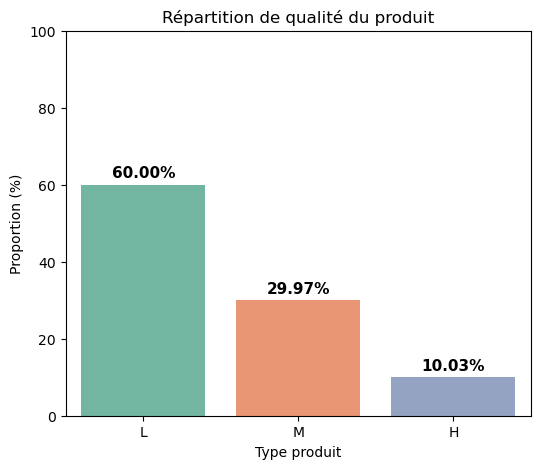

In [155]:
# Variable qualitative : qualité du produit
print(df['Type'].value_counts())
print(df['Type'].value_counts(normalize=True) * 100)

# Représentation graphique avec seaborn
pct = df['Type'].value_counts(normalize=True).mul(100).reset_index()
pct.columns = ['Type', 'Pourcentage']

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=pct, x='Type', y='Pourcentage', palette='Set2')

# Affichage des pourcentages sur les barres
for i, row in pct.iterrows():
    ax.text(i, row['Pourcentage'] + 1, f"{row['Pourcentage']:.2f}%", 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel("Type produit")
plt.ylabel("Proportion (%)")
plt.title("Répartition de qualité du produit")
plt.ylim(0, 100)
plt.show()

60% des produit sont de type L, 30% de type M et 10% de H

### Pannes machine

C:\Users\HP\AppData\Local\Temp\ipykernel_30552\1726914191.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=pct, x='Machine failure', y='Pourcentage', palette='Set2')


Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


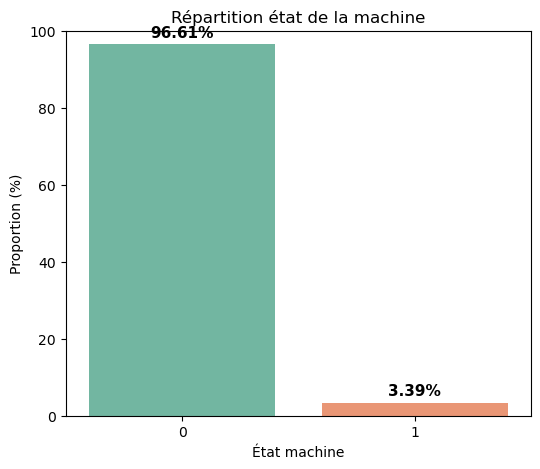

In [156]:
# Variable qualitative : pannes machine
print(df['Machine failure'].value_counts())
print(df['Machine failure'].value_counts(normalize=True) * 100)

# Représentation graphique avec seaborn
pct = df['Machine failure'].value_counts(normalize=True).mul(100).reset_index()
pct.columns = ['Machine failure', 'Pourcentage']

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=pct, x='Machine failure', y='Pourcentage', palette='Set2')

# Affichage des pourcentages sur les barres
for i, row in pct.iterrows():
    ax.text(i, row['Pourcentage'] + 1, f"{row['Pourcentage']:.2f}%", 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel("État machine")
plt.ylabel("Proportion (%)")
plt.title("Répartition état de la machine")
plt.ylim(0, 100)
plt.show()

In [157]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

**Nous avons une répartition très déséquilibrés (peu de pannes vs beaucoup de cas normaux)**

### Tool wear [min]

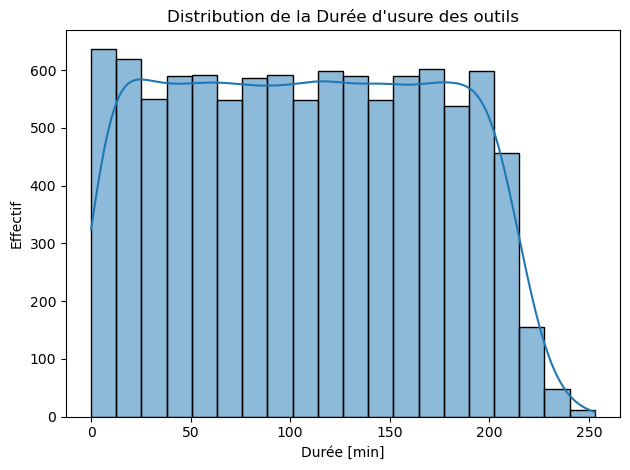

In [158]:
# Variable continue : Durée d'usure des outils
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()
sns.histplot(df['Tool wear [min]'], bins=20, kde=True, ax=ax)
ax.set_yticks(np.arange(0, 700, 100))
ax.set_title("Distribution de la Durée d'usure des outils")
ax.set_xlabel("Durée [min]")
ax.set_ylabel("Effectif")
plt.tight_layout()
plt.show()

In [159]:
# === TENDANCE ===
print("Mode :", df['Tool wear [min]'].mode()[0])
print("Médiane :", df['Tool wear [min]'].median())
print("Moyenne :", df['Tool wear [min]'].mean())

Mode : 0
Médiane : 108.0
Moyenne : 107.951


Variance corrigée : 4051.85
Écart-type        : 63.65
CV                : 0.5897  (59.0 %)


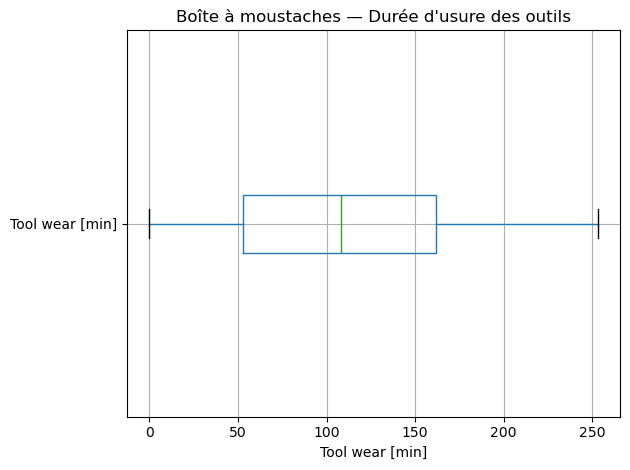

In [160]:
# === DISPERSION ===
variance  = df['Tool wear [min]'].var(ddof=1)
ecart_type = df['Tool wear [min]'].std()
moyenne    = df['Tool wear [min]'].mean()
cv         = ecart_type / moyenne

print(f"Variance corrigée : {variance:.2f}")
print(f"Écart-type        : {ecart_type:.2f}")
print(f"CV                : {cv:.4f}  ({cv*100:.1f} %)")

df.boxplot(column='Tool wear [min]', vert=False)
plt.title("Boîte à moustaches — Durée d'usure des outils")
plt.xlabel("Tool wear [min]")
plt.tight_layout()
plt.show()

**Pas de cas extreme, mais la variance élevé montre une dispersion de la distribution**

In [161]:
# === FORME ===
print("Skewness :", df['Tool wear [min]'].skew()) 
print("Kurtosis :", df['Tool wear [min]'].kurtosis())

Skewness : 0.027292239050452527
Kurtosis : -1.1667371315780541


La distribution est symétrique mais beaucoup dispersée confirmé par le kurtosis inférieure à 1

C:\Users\HP\AppData\Local\Temp\ipykernel_30552\2019898423.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(lorenz, xaxis)


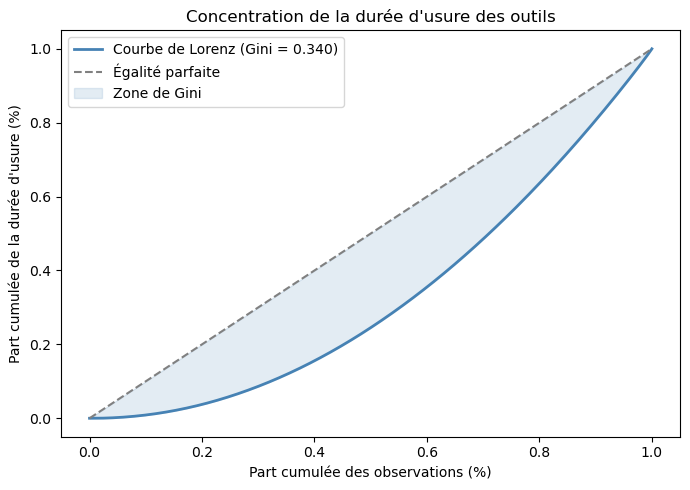

Coefficient de Gini : 0.3403


In [162]:
# === CONCENTRATION (DURÉE D'USURE DES OUTILS) ===
couts = df['Tool wear [min]'].values
n     = len(couts)

# 1. Tri croissant + somme cumulée normalisée → courbe de Lorenz
lorenz = np.cumsum(np.sort(couts)) / couts.sum()
lorenz = np.append([0], lorenz)          # point d'origine (0, 0)

# 2. Axe X corrigé : strictement de 0 à 1, n+1 points
xaxis = np.linspace(0, 1, n + 1)

# 3. Calcul du coefficient de Gini (aire entre les deux courbes)
gini = 1 - 2 * np.trapz(lorenz, xaxis)

# 4. Tracé
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(xaxis, lorenz,    label=f'Courbe de Lorenz (Gini = {gini:.3f})',
        color='steelblue', linewidth=2)
ax.plot([0, 1], [0, 1],   label='Égalité parfaite',
        color='gray', linestyle='--', linewidth=1.5)
ax.fill_between(xaxis, lorenz, xaxis, alpha=0.15, color='steelblue',
                label='Zone de Gini')

ax.set_xlabel("Part cumulée des observations (%)")
ax.set_ylabel("Part cumulée de la durée d'usure (%)")
ax.set_title("Concentration de la durée d'usure des outils")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Coefficient de Gini : {gini:.4f}")

In [163]:
couts  = df['Tool wear [min]'].values
n      = len(couts)
lorenz = np.cumsum(np.sort(couts)) / couts.sum()
lorenz = np.append([0], lorenz)
xaxis  = np.linspace(0, 1, n + 1)

def lire_lorenz(pct_outils):
    """
    Retourne la part cumulée d'usure pour les X% d'outils les moins usés.
    pct_outils : valeur entre 0 et 1 (ex. 0.50 pour 50%)
    """
    idx = int(round(pct_outils * n))
    return lorenz[idx]

seuils = [0.50, 0.70, 0.90]

print("=== Lecture de la courbe de Lorenz ===\n")
for s in seuils:
    y = lire_lorenz(s)
    print(f"Les {s*100:.0f}% les moins usés  → {y*100:.1f}% de l'usure totale")
    print(f"Les {(1-s)*100:.0f}% les plus usés    → {(1-y)*100:.1f}% de l'usure totale\n")

=== Lecture de la courbe de Lorenz ===

Les 50% les moins usés  → 24.5% de l'usure totale
Les 50% les plus usés    → 75.5% de l'usure totale

Les 70% les moins usés  → 48.5% de l'usure totale
Les 30% les plus usés    → 51.5% de l'usure totale

Les 90% les moins usés  → 80.7% de l'usure totale
Les 10% les plus usés    → 19.3% de l'usure totale



## Analyse statistique bivariée

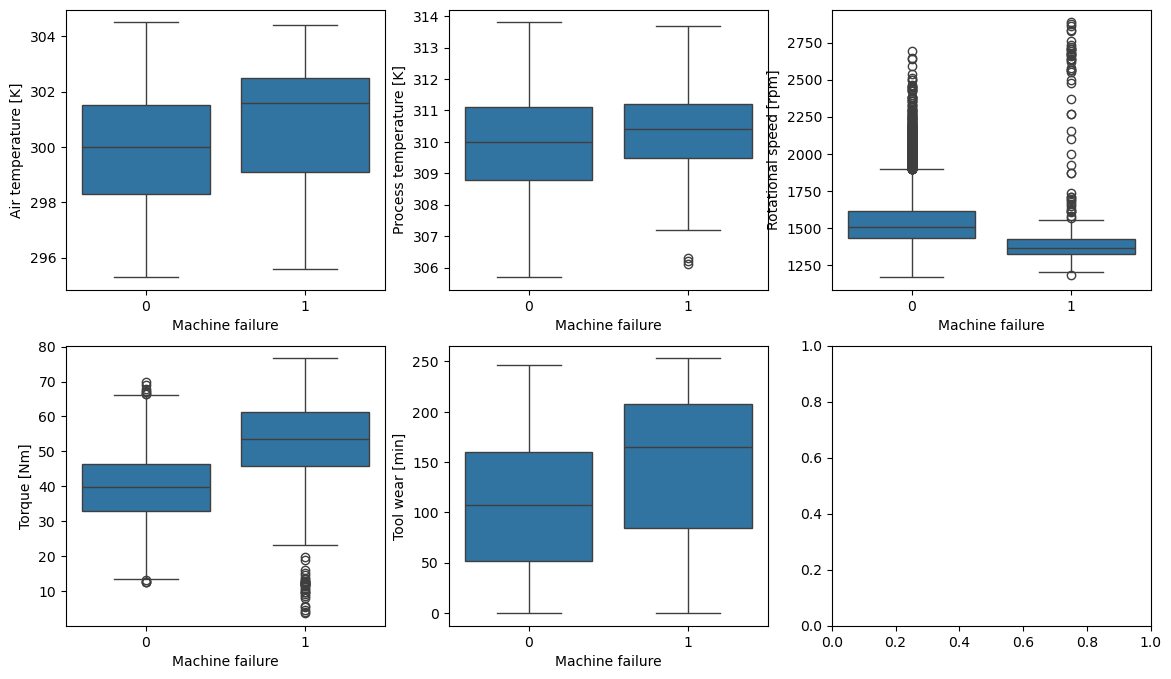

In [164]:
# Distribution des capteurs par type de panne
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(['Air temperature [K]', 'Process temperature [K]',
                              'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']):
    sns.boxplot(x='Machine failure', y=col, data=df, ax=axes.flat[i])

**Le couple (Torque) et l'usure des outils (Tool wear) sont les variables les plus discriminantes pour prédire une panne, avec des médianes nettement décalées entre les deux groupes. La vitesse (Rotational speed) montre un comportement bimodal intéressant (extrêmes hauts ET bas associés aux pannes). Les températures apportent peu d'information discriminante seules.**

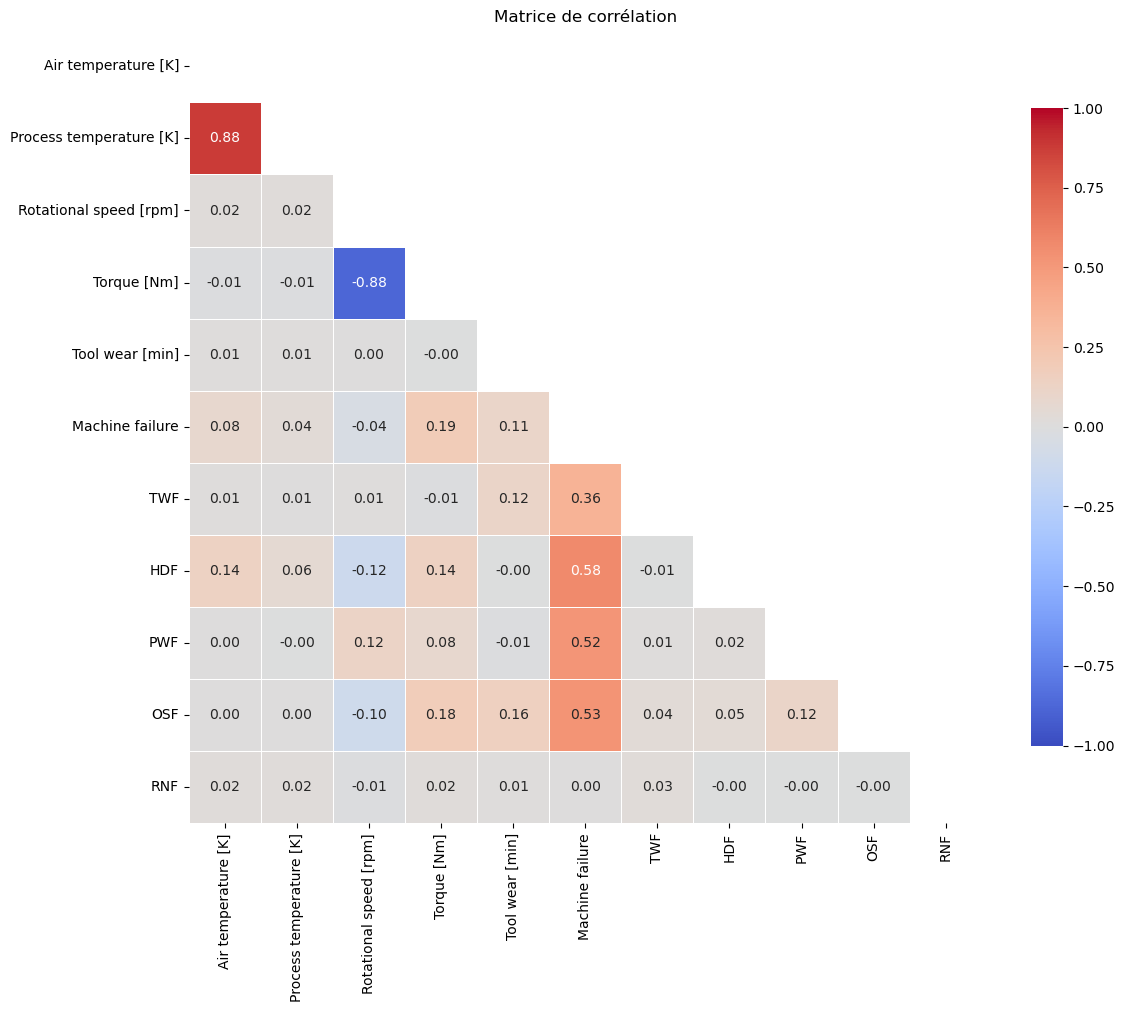

In [165]:
# Matrice de corrélation
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(df.select_dtypes(include='number').corr(), dtype=bool))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, fmt='.2f', cmap='coolwarm', 
            mask=mask, vmin=-1, vmax=1, 
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

Nous constatons une corrélation inversée entre Couple et vitesse et une autre corrélation ente température de l'air et température d'exploitation. toutes 2 évidentes

**Ces sous-types de panne (TWF, HDF, PWF, OSF, RNF) sont en réalité les causes de Machine failure . Si nous les utilisez comme features pour prédire Machine failure, nous risquez du data leakage massif puisqu'ils encodent directement la cible. Nous allons les exclure du modèles.**